In [1]:
import sys

print("Hello, research!")
print("Python location:", sys.executable)

Hello, research!
Python location: /mnt/cv_data/users/seven/envs/ml/bin/python


# My First Research Notebook

This notebook checks that Python runs correctly in my ml environment.

The code prints a greeting and shows the Python interpreter path.

## 1. Environment Check
This cell checks that PyTorch, torchvision, and the data-processing libraries are installed, and whether a GPU is visible.

In [2]:
import torch, torchvision
import pandas, openpyxl, sklearn, matplotlib

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

torch: 2.12.1+cu130
torchvision: 0.27.1+cu130
CUDA available: False


## 2. Explore the Dataset
This cell lists the files in the dataset folder to find the images and the two .xlsx files (train and test).

In [3]:
import os

data_root = os.path.expanduser("~/datasets/Dataset_BUSI_with_GT_Clean")
print("Exists:", os.path.exists(data_root))

for name in sorted(os.listdir(data_root)):
    print(name)

Exists: True
images
labels
test.xlsx
train.xlsx


## 3. Inspect the Train/Test Spreadsheets
The .xlsx files list image filenames and labels. We check their columns before writing the Dataset class.

In [4]:
import os
import pandas as pd

data_root = os.path.expanduser("~/datasets/Dataset_BUSI_with_GT_Clean")

train_df = pd.read_excel(os.path.join(data_root, "train.xlsx"))
test_df = pd.read_excel(os.path.join(data_root, "test.xlsx"))

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Columns:", list(train_df.columns))
train_df.head()

Train shape: (517, 2)
Test shape: (130, 2)
Columns: ['Image', 'Label']


,Image,Label
0,benign (218).png,1
1,benign (58).png,1
2,benign (179).png,1
3,benign (410).png,1
4,benign (16).png,1


## 4. Check Label Distribution
This cell counts how many images belong to each label and checks which label matches benign or malignant, so we know what 0 and 1 mean.

In [5]:
# 每个标签有多少张图
print("Train label counts:")
print(train_df["Label"].value_counts())
print("\nTest label counts:")
print(test_df["Label"].value_counts())

# 文件名里含 benign / malignant，看它和 Label 的对应关系
for name, df in [("train", train_df), ("test", test_df)]:
    kind = df["Image"].str.extract(r"^(benign|malignant|normal)", expand=False)
    print(f"\n{name}: filename type vs Label")
    print(pd.crosstab(kind, df["Label"]))

Train label counts:
Label
1    346
0    171
Name: count, dtype: int64

Test label counts:
Label
1    91
0    39
Name: count, dtype: int64

train: filename type vs Label
Label        0    1
Image              
benign       0  346
malignant  171    0

test: filename type vs Label
Label       0   1
Image            
benign      0  91
malignant  39   0


## 5. Check the Image Folder
This cell checks that the image files listed in the spreadsheets actually exist in the images folder.

In [6]:
img_dir = os.path.join(data_root, "images")
files = os.listdir(img_dir)
print("Number of files in images/:", len(files))
print("Examples:", sorted(files)[:5])

# 表格里的每个文件名，是否都能在 images/ 里找到
missing_train = [f for f in train_df["Image"] if f not in files]
missing_test = [f for f in test_df["Image"] if f not in files]
print("Missing in train:", len(missing_train))
print("Missing in test:", len(missing_test))

Number of files in images/: 647
Examples: ['benign (1).png', 'benign (10).png', 'benign (100).png', 'benign (101).png', 'benign (102).png']
Missing in train: 0
Missing in test: 0


## 6. Dataset and DataLoader
This cell defines a custom Dataset that reads image filenames and labels from the spreadsheet, loads each image, resizes it to 224x224, and converts it to a normalized tensor. DataLoaders then feed the images to the model in batches.

In [7]:
import os
import pandas as pd
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

data_root = os.path.expanduser("~/datasets/Dataset_BUSI_with_GT_Clean")
img_dir = os.path.join(data_root, "images")

train_df = pd.read_excel(os.path.join(data_root, "train.xlsx"))
test_df = pd.read_excel(os.path.join(data_root, "test.xlsx"))

# 预处理：resize 到 224x224，转 tensor，再按 ImageNet 的均值和方差归一化
# （预训练的 ResNet50 是用这种归一化训练的）
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

class BUSIDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True)   # 重置索引，保证 0..N-1
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)                    # 数据集大小

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = os.path.join(self.img_dir, row["Image"])
        image = Image.open(path).convert("RGB")  # 超声图可能是灰度，统一转 3 通道
        if self.transform:
            image = self.transform(image)
        label = int(row["Label"])
        return image, label

train_set = BUSIDataset(train_df, img_dir, transform)
test_set = BUSIDataset(test_df, img_dir, transform)

# 训练集打乱顺序，测试集不用打乱
train_loader = DataLoader(train_set, batch_size=16, shuffle=True, num_workers=2)
test_loader = DataLoader(test_set, batch_size=16, shuffle=False, num_workers=2)

# 取一个 batch 检查形状
images, labels = next(iter(train_loader))
print("Train size:", len(train_set), "Test size:", len(test_set))
print("Batch images:", images.shape)   # 应为 [16, 3, 224, 224]
print("Batch labels:", labels)

Train size: 517 Test size: 130
Batch images: torch.Size([16, 3, 224, 224])
Batch labels: tensor([1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1])


## 7. Build the Model
This cell loads ResNet50 with ImageNet pre-trained weights and replaces the final fully connected layer so it outputs 2 classes (malignant vs benign). The model is moved to the GPU if one is available.

In [8]:
import torch.nn as nn
from torchvision import models

# 选择设备：有 GPU 用 GPU，没有就用 CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# 加载在 ImageNet 上预训练的 ResNet50
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# 原来的最后一层输出 1000 类，改成 2 类（0=恶性，1=良性）
in_features = model.fc.in_features   # ResNet50 是 2048
model.fc = nn.Linear(in_features, 2)

model = model.to(device)

# 检查输出形状
model.eval()
with torch.no_grad():
    out = model(images.to(device))
print("Output shape:", out.shape)   # 应为 [16, 2]

Using device: cpu
Output shape: torch.Size([16, 2])


## 8. Loss, Optimizer, and Train/Eval Functions
This cell defines the loss function (cross-entropy), the optimizer (Adam), and two functions: one that trains the model for one epoch, and one that evaluates it on a dataset and returns the loss, predictions, and true labels.

In [9]:
import torch.optim as optim

# 损失函数：二分类（两个输出）用交叉熵
criterion = nn.CrossEntropyLoss()

# 优化器：Adam，学习率 1e-4（微调预训练模型，学习率要小）
optimizer = optim.Adam(model.parameters(), lr=1e-4)

def train_one_epoch(model, loader):
    """训练一个 epoch，返回平均训练损失"""
    model.train()                          # 训练模式（BatchNorm 更新统计量）
    total_loss = 0.0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()              # 清空上一步的梯度
        outputs = model(imgs)              # 前向传播
        loss = criterion(outputs, labels)  # 计算损失
        loss.backward()                    # 反向传播，计算梯度
        optimizer.step()                   # 更新参数
        total_loss += loss.item() * imgs.size(0)
    return total_loss / len(loader.dataset)

def evaluate(model, loader):
    """在数据集上评估，返回平均损失、预测标签、真实标签"""
    model.eval()                           # 评估模式
    total_loss = 0.0
    all_preds, all_labels = [], []
    with torch.no_grad():                  # 不计算梯度，省显存
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * imgs.size(0)
            all_preds.extend(outputs.argmax(dim=1).cpu().tolist())
            all_labels.extend(labels.cpu().tolist())
    return total_loss / len(loader.dataset), all_preds, all_labels

print("Functions defined.")

Functions defined.


## 9. Training on the GPU (train.py + Slurm)
Training was run as a separate script, `train.py`, submitted to a GPU node with Slurm (`sbatch submit.sh`), so it keeps running even if the VPN disconnects. The script uses the same dataset, model, loss and optimizer defined above, trains for 30 epochs and 5 epochs, and saves three files in `outputs/`and `outputs_5ep/`: `history.json` (per-epoch losses), `resnet50_busi.pth` (model weights), and `test_predictions.csv` (predictions on the test set).

## 10(a).（30 epochs）Training and Test Loss Curves
This cell loads the per-epoch loss values saved by train.py and plots them. The curves show how the model learned over time and help us judge underfitting or overfitting.

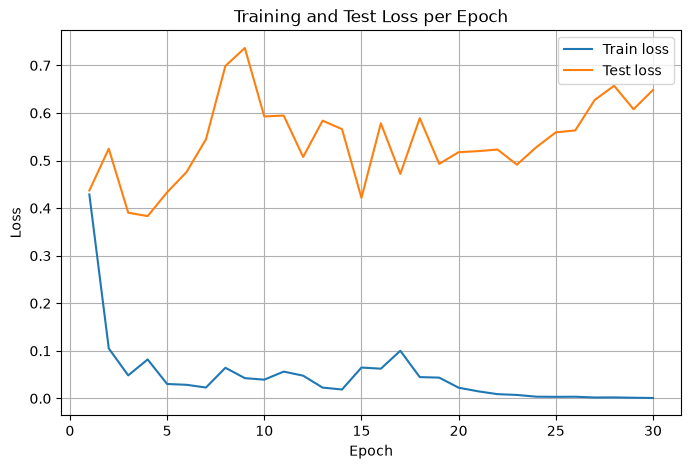

In [10]:
import json, os
import matplotlib.pyplot as plt

OUT_DIR_30 = os.path.expanduser("~/projects/research_training/outputs")

# 读取训练时保存的记录
with open(os.path.join(OUT_DIR_30, "history.json")) as f:
    history = json.load(f)

epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_loss"], label="Train loss")
plt.plot(epochs, history["test_loss"], label="Test loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Test Loss per Epoch")
plt.legend()
plt.grid(True)
plt.show()

## 11(a).（30 epochs） Evaluation Metrics 
This cell reads the saved test predictions and computes accuracy, precision, recall, F1 score, and the confusion matrix. Label 0 = malignant, 1 = benign.

In [11]:
import pandas as pd
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

pred_df = pd.read_csv(os.path.join(OUT_DIR_30, "test_predictions.csv"))
y_true = pred_df["True"]
y_pred = pred_df["Pred"]

print("Accuracy :", round(accuracy_score(y_true, y_pred), 4))
print("Precision:", round(precision_score(y_true, y_pred), 4))
print("Recall   :", round(recall_score(y_true, y_pred), 4))
print("F1 score :", round(f1_score(y_true, y_pred), 4))

print("\nConfusion matrix (rows=true, cols=pred):")
print(confusion_matrix(y_true, y_pred))

print("\nPer-class report:")
print(classification_report(y_true, y_pred,
                            target_names=["malignant (0)", "benign (1)"]))


Accuracy : 0.8692
Precision: 0.9111
Recall   : 0.9011
F1 score : 0.9061

Confusion matrix (rows=true, cols=pred):
[[31  8]
 [ 9 82]]

Per-class report:
               precision    recall  f1-score   support

malignant (0)       0.78      0.79      0.78        39
   benign (1)       0.91      0.90      0.91        91

     accuracy                           0.87       130
    macro avg       0.84      0.85      0.85       130
 weighted avg       0.87      0.87      0.87       130



## 10(b).（5 epochs） Training and Test Loss Curves
This cell loads the per-epoch loss values saved by train.py and plots them. The curves show how the model learned over time and help us judge underfitting or overfitting.

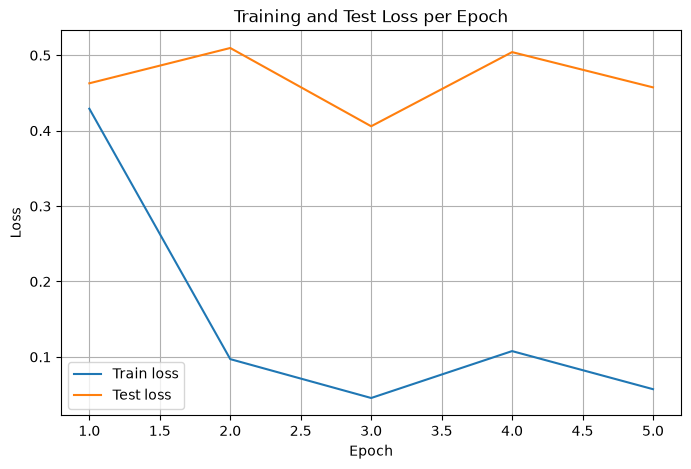

In [12]:
import json, os
import matplotlib.pyplot as plt

OUT_DIR_5 = os.path.expanduser("~/projects/research_training/outputs_5ep")

# 读取训练时保存的记录
with open(os.path.join(OUT_DIR_5, "history.json")) as f:
    history = json.load(f)

epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_loss"], label="Train loss")
plt.plot(epochs, history["test_loss"], label="Test loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Test Loss per Epoch")
plt.legend()
plt.grid(True)
plt.show()

## 11(b).（5 epochs） Evaluation Metrics 
This cell reads the saved test predictions and computes accuracy, precision, recall, F1 score, and the confusion matrix. Label 0 = malignant, 1 = benign.

In [13]:
import pandas as pd
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

pred_df = pd.read_csv(os.path.join(OUT_DIR_5, "test_predictions.csv"))
y_true = pred_df["True"]
y_pred = pred_df["Pred"]

print("Accuracy :", round(accuracy_score(y_true, y_pred), 4))
print("Precision:", round(precision_score(y_true, y_pred), 4))
print("Recall   :", round(recall_score(y_true, y_pred), 4))
print("F1 score :", round(f1_score(y_true, y_pred), 4))

print("\nConfusion matrix (rows=true, cols=pred):")
print(confusion_matrix(y_true, y_pred))

print("\nPer-class report:")
print(classification_report(y_true, y_pred,
                            target_names=["malignant (0)", "benign (1)"]))


Accuracy : 0.9077
Precision: 0.9341
Recall   : 0.9341
F1 score : 0.9341

Confusion matrix (rows=true, cols=pred):
[[33  6]
 [ 6 85]]

Per-class report:
               precision    recall  f1-score   support

malignant (0)       0.85      0.85      0.85        39
   benign (1)       0.93      0.93      0.93        91

     accuracy                           0.91       130
    macro avg       0.89      0.89      0.89       130
 weighted avg       0.91      0.91      0.91       130



## 12. Visualize Test Predictions
This cell loops over every test image and shows it with its true class and predicted class. Wrong predictions are marked in red so we can see which images were misclassified.

Misclassified: 12 of 130


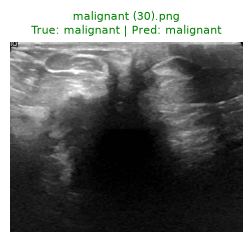

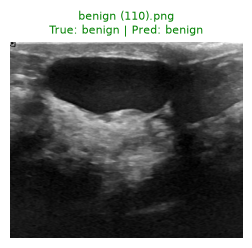

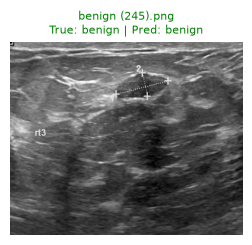

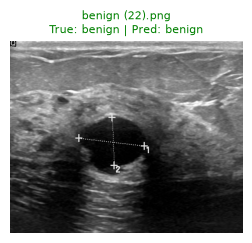

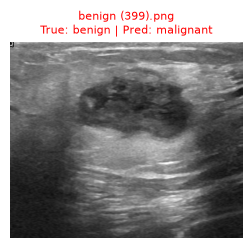

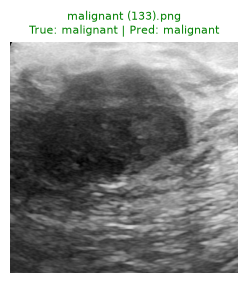

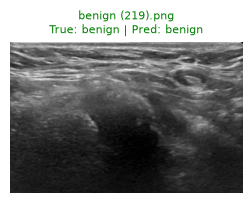

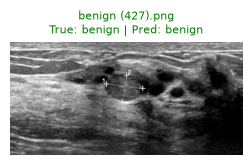

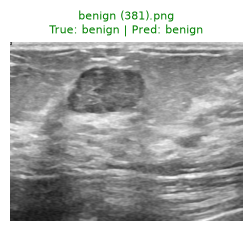

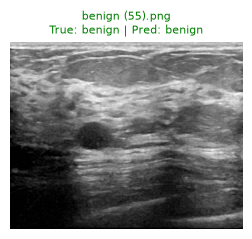

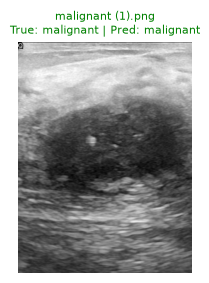

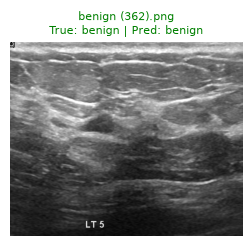

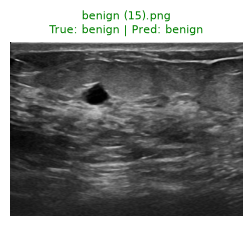

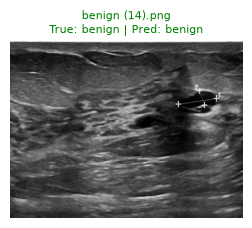

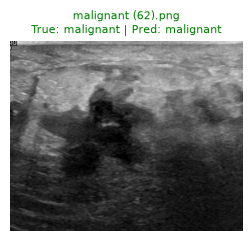

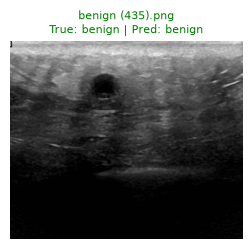

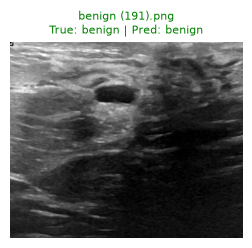

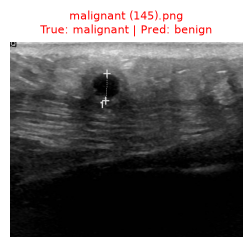

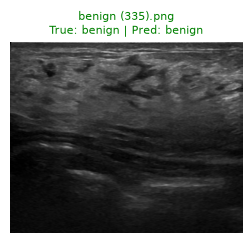

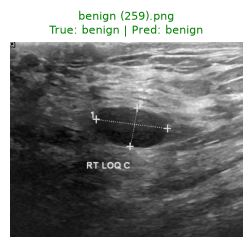

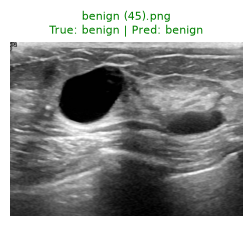

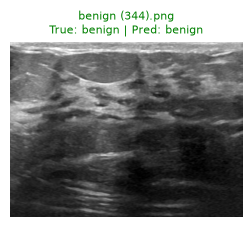

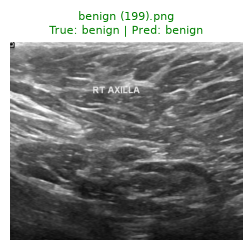

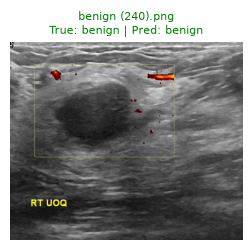

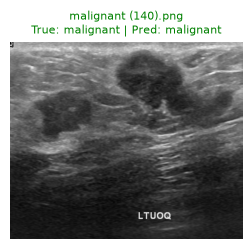

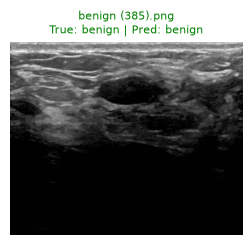

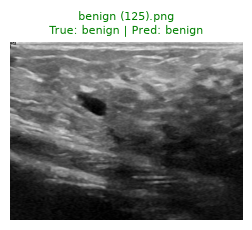

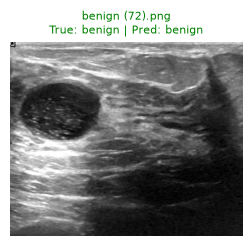

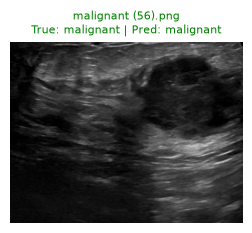

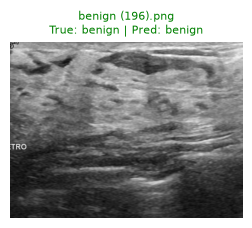

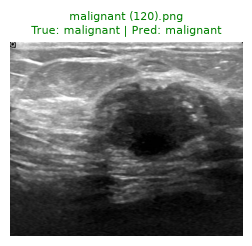

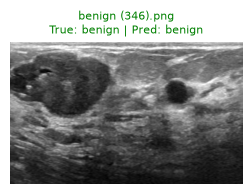

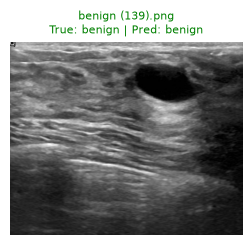

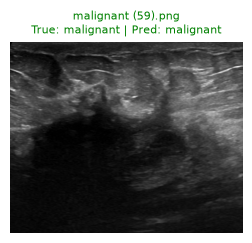

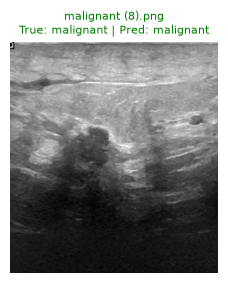

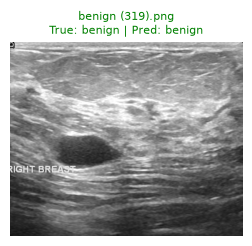

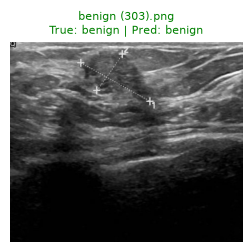

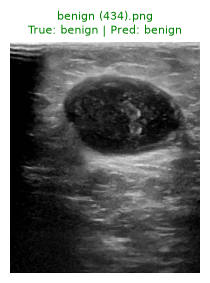

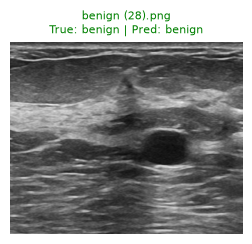

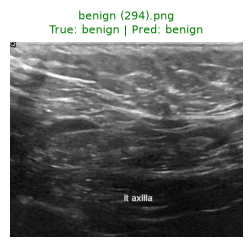

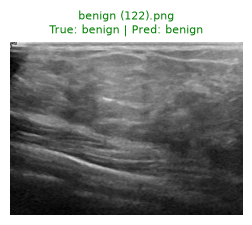

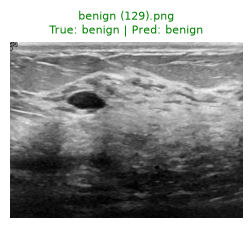

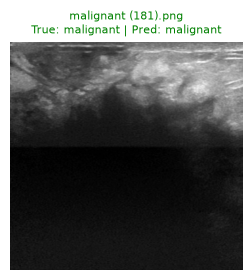

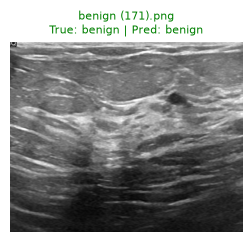

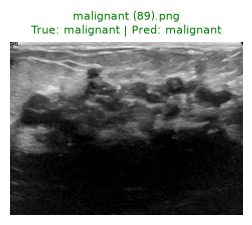

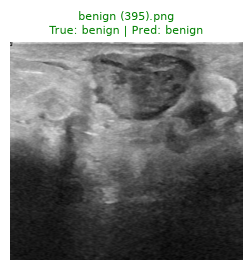

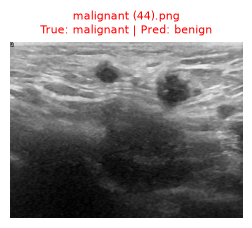

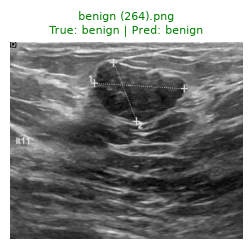

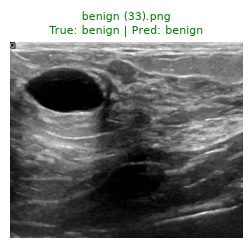

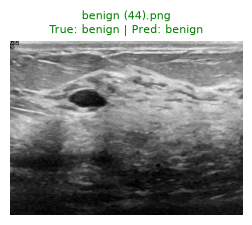

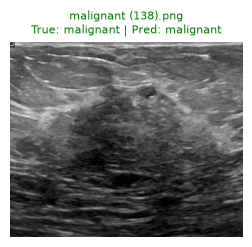

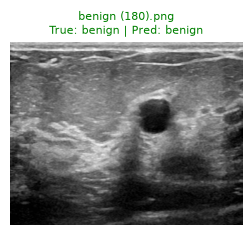

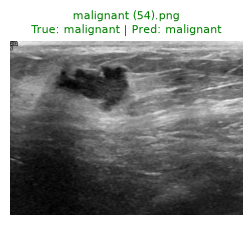

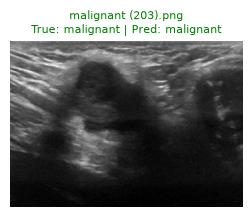

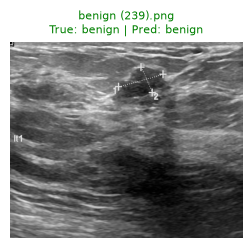

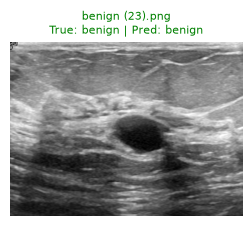

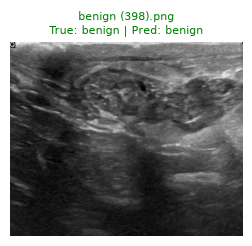

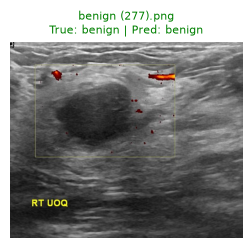

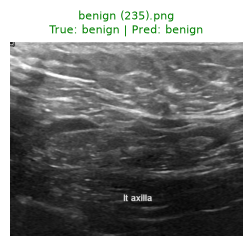

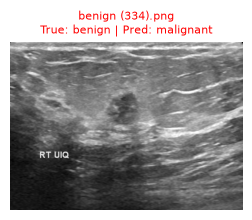

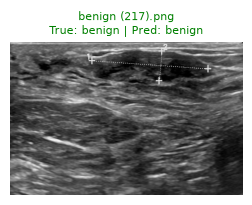

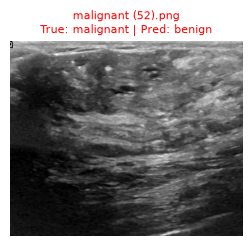

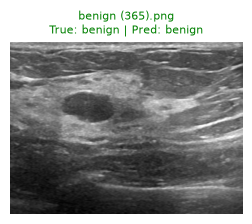

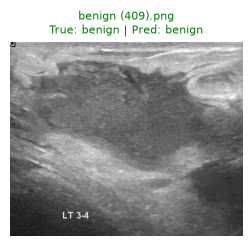

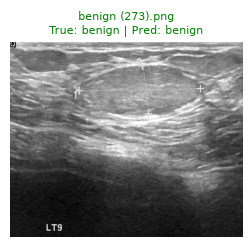

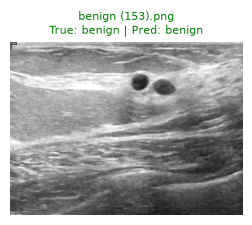

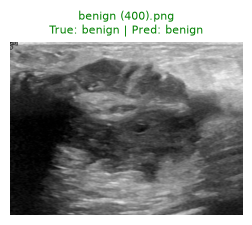

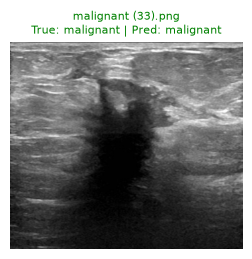

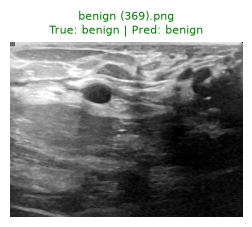

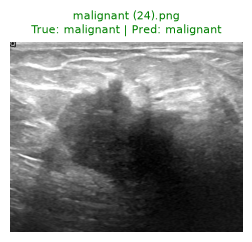

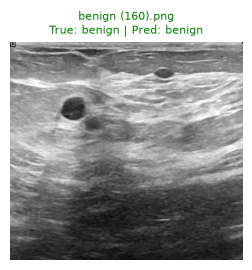

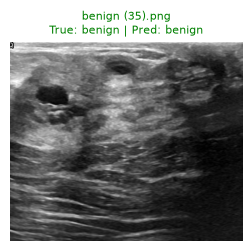

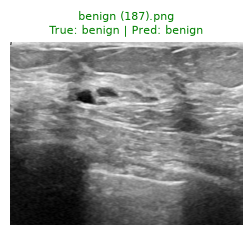

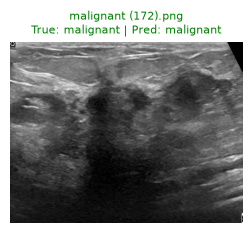

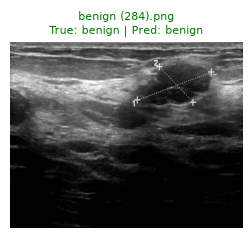

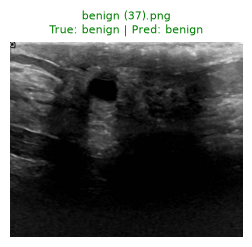

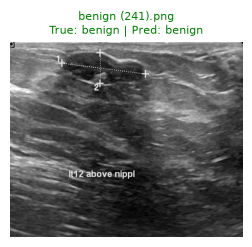

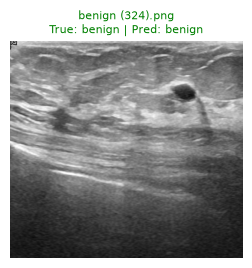

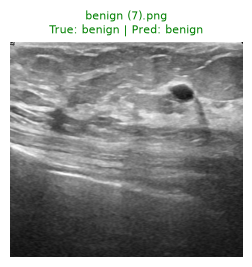

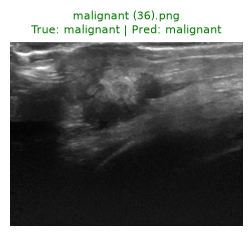

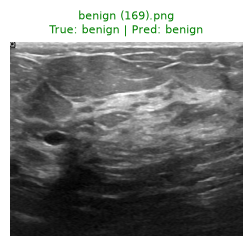

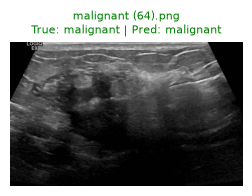

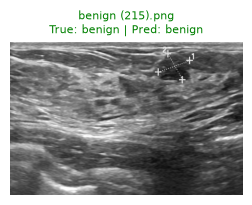

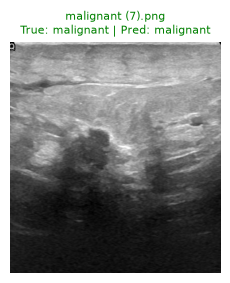

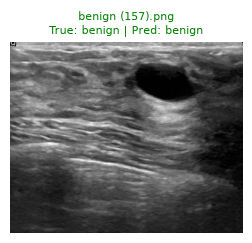

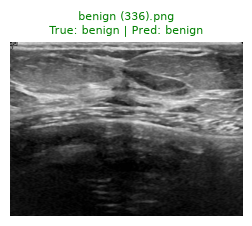

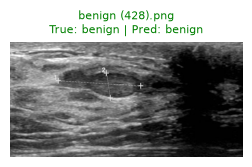

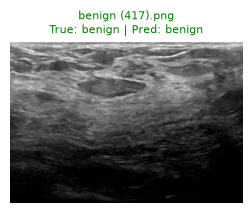

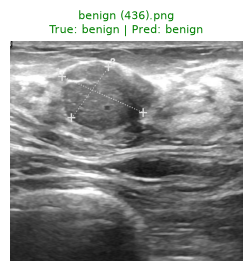

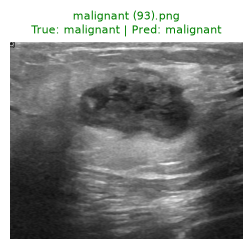

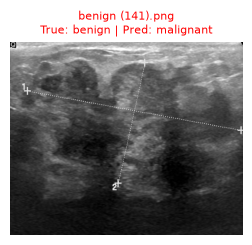

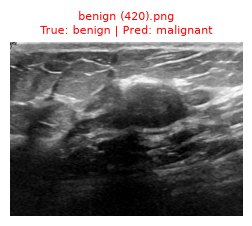

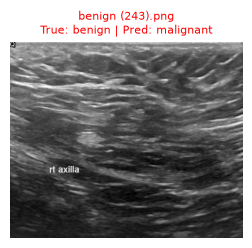

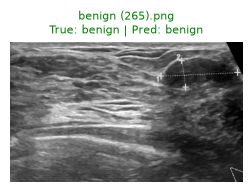

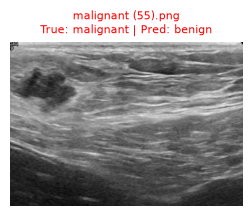

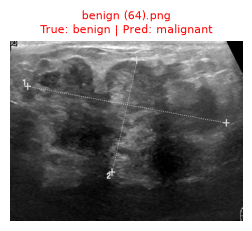

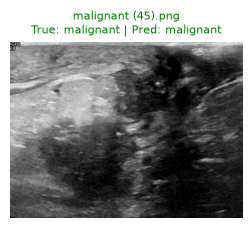

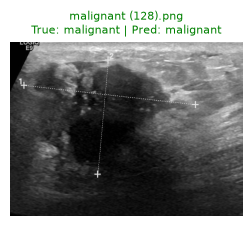

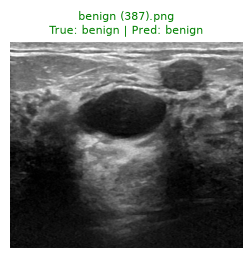

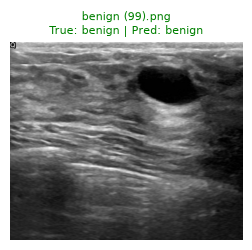

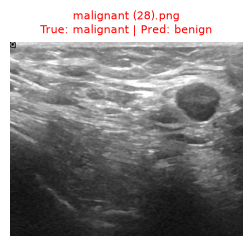

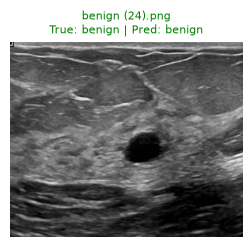

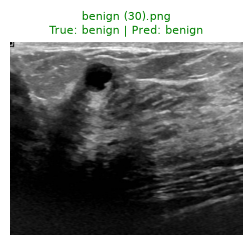

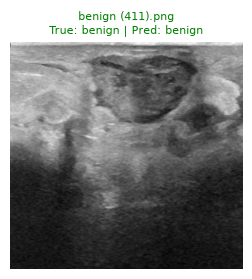

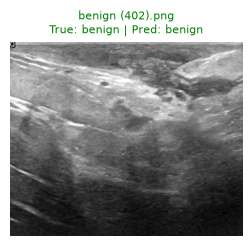

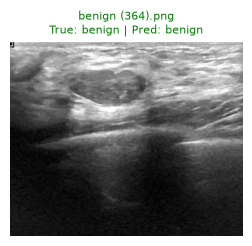

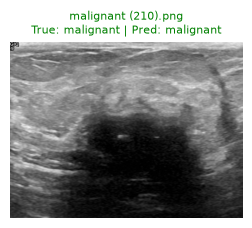

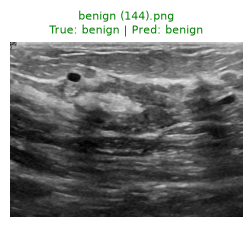

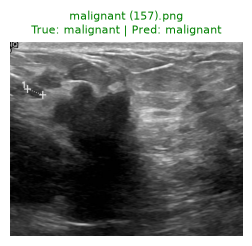

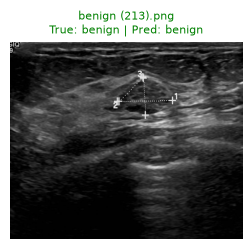

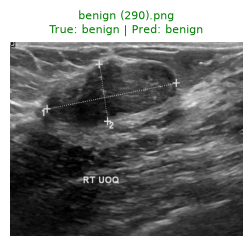

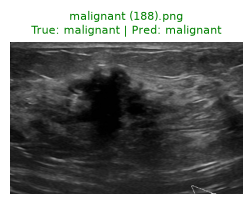

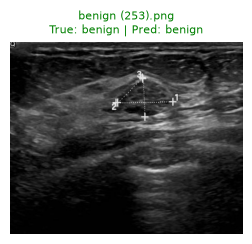

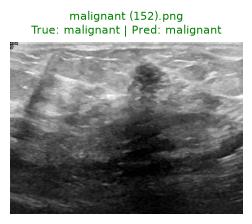

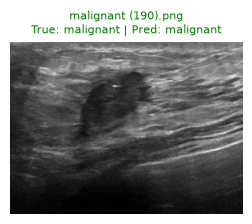

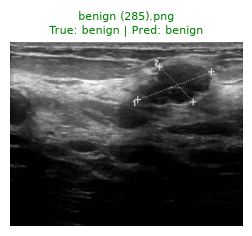

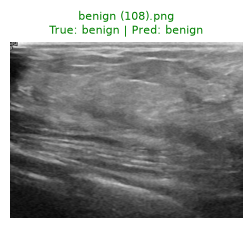

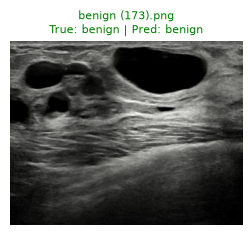

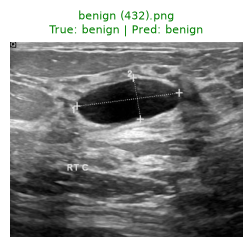

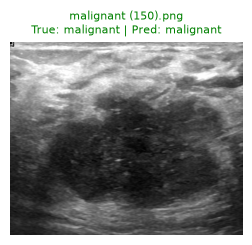

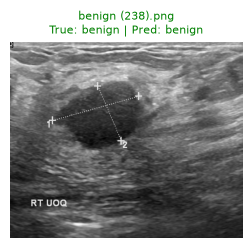

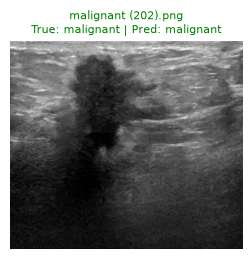

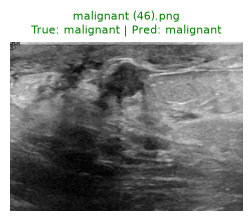

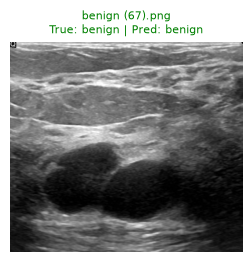

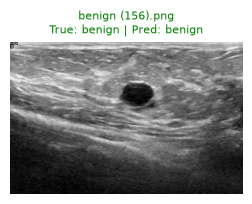

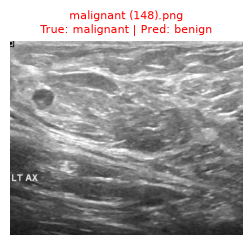

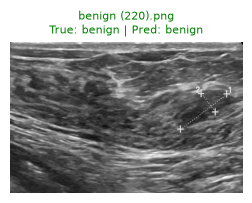

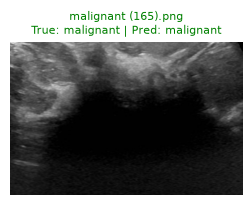

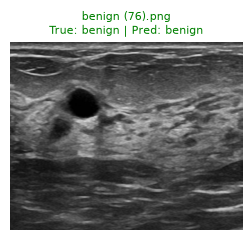

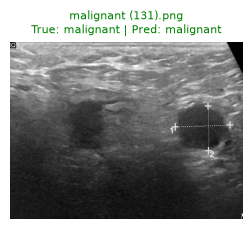

In [14]:
from PIL import Image
import matplotlib.pyplot as plt

pred_df = pd.read_csv(os.path.join(OUT_DIR_5, "test_predictions.csv"))
print("Misclassified:", (pred_df["True"] != pred_df["Pred"]).sum(), "of", len(pred_df))
DATA_ROOT = os.path.expanduser("~/datasets/Dataset_BUSI_with_GT_Clean")
IMG_DIR = os.path.join(DATA_ROOT, "images")
class_names = {0: "malignant", 1: "benign"}

for i, row in pred_df.iterrows():
    img = Image.open(os.path.join(IMG_DIR, row["Image"])).convert("RGB")
    true_name = class_names[row["True"]]
    pred_name = class_names[row["Pred"]]
    correct = row["True"] == row["Pred"]

    plt.figure(figsize=(3, 3))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"{row['Image']}\nTrue: {true_name} | Pred: {pred_name}",
              color="green" if correct else "red", fontsize=8)
    plt.show()

## 13. Summary and Analysis

**Task.** Binary classification of breast ultrasound (BUSI) images into malignant (0) and benign (1) using ResNet50 pre-trained on ImageNet, with all images resized to 224x224. The model was trained on `train.xlsx` (517 images) and evaluated on `test.xlsx` (130 images: 39 malignant, 91 benign). Training was run on a GPU node with `train.py` and Slurm.

**Results.**

| Setting | Accuracy | Malignant precision / recall / F1 | Benign precision / recall / F1 | Misclassified | Malignant missed |
|---|---|---|---|---|---|
| 30 epochs | 0.869 | 0.78 / 0.79 / 0.78 | 0.91 / 0.90 / 0.91 | 17 | 8 |
| 5 epochs | 0.908 | 0.85 / 0.85 / 0.85 | 0.93 / 0.93 / 0.93 | 12 | 6 |

**Loss curves.** With 30 epochs, train loss dropped to nearly 0 while test loss reached its minimum around epoch 3-4, then rose and fluctuated between about 0.5 and 0.7. This is a typical sign of overfitting: the model memorizes the training set but generalizes worse. After retraining for 5 epochs, the model avoided the late-stage increase in test loss and performed better on the test set. However, a gap between train loss (about 0.05-0.1) and test loss (about 0.4-0.5) remains, so some overfitting is still present.

**Why accuracy alone is not enough.** Benign images are about twice as many as malignant ones, so accuracy can hide poor performance on the malignant class. Malignant recall is the most important metric here, because missing a malignant tumor (predicting benign) is the most serious error.

**Error patterns (inspected examples).** Among the misclassified images I inspected, missed malignant cases were often small or smoothly bordered lesions, or had indistinct margins, which may look more benign and may lose detail after resizing to 224x224. Benign cases predicted as malignant tended to have irregular shape, heterogeneous texture, or posterior darkening. Some images contain annotation marks (measurement crosses, text labels), but they also appear in correctly classified images, so there is no clear evidence that they cause errors. These observations come from a non-random subset of images and are not diagnostic conclusions.

**Limitations.**
- The test set is small (39 malignant images), so a difference of two images noticeably changes recall; the improvement from 30 to 5 epochs should be interpreted cautiously.
- The number of epochs was chosen by looking at test loss, so the 5-epoch result may be slightly optimistic. A separate validation set should be used for this in future work.
- Results come from a single training run with one random seed.

**Next steps.** Add data augmentation (flips, rotations, brightness changes), use a separate validation set to select the number of epochs, try a higher input resolution to preserve small lesions, repeat with several random seeds to measure variability, and explore using the segmentation masks in the dataset.